In [1]:
from configs import avail_models, get_avail_splits
from video_dataset import (
    get_wlasl_info,
    VideoDataset,
    )
import utils
import configs
import torch
from torch.utils.data import DataLoader
import json
from video_transforms import get_transform
from run_types import AdminInfo

Please update your PyTorchVideo to latest master


In [2]:
configs.set_seed()

## Setup

### Model

Available models:

In [3]:
av_models = avail_models()
for idx, m in enumerate(av_models):
    print(f"{idx}: {m}")

0: S3D
1: R3D_18
2: R(2+1)D_18
3: Swin3D_T
4: Swin3D_S
5: Swin3D_B
6: MViTv2_S
7: MViTv2_S_e
8: MViTv1_B
9: MViTv2_S_16x4
10: MViTv2_B_32x3


Chosen model: 

In [4]:
model_name = av_models[0]
print(model_name)

S3D


### Dataset

Available splits

In [5]:
av_splits = get_avail_splits()
for s in av_splits:
    print(s)

asl100
asl2000
asl300
asl1000


Chosen split, and set

In [6]:
split_name = av_splits[0]
print(split_name)

asl100


Dataset info

In [7]:
test_info = get_wlasl_info(split_name, set_name="test")
print(test_info)


{'root': PosixPath('../data/WLASL/WLASL2000'), 'labels': PosixPath('../data/WLASL/preprocessed/labels/asl100'), 'label_suff': 'fixed_frange_bboxes_len.json', 'set_name': 'test'}


Class list

In [8]:
class_list = configs.get_class_list()
print(len(class_list))

2000


## Config

In [9]:
config = configs.load_config(
    AdminInfo(
        model=model_name,
        dataset='wlasl',
        split=split_name,
        save_path='results',
        exp_no='0',
        recover=False,
        config_path='/home/luke/Code/SLR/code/configfiles/asl100/S3D/exp058.ini',
        weight_path=None
    )
)
data_info = config.data
print(json.dumps(data_info.model_dump(), indent=4))

{
    "num_frames": 32,
    "frame_size": 224,
    "train_augs": {
        "frame_size_strategy": "Random_crop",
        "frame_sampler": {
            "max_wobble": 0,
            "method": "og",
            "randomise": false
        },
        "norm_dict": {
            "mean": [
                0.43216,
                0.394666,
                0.37645
            ],
            "std": [
                0.22803,
                0.22145,
                0.216989
            ]
        },
        "temporal_aug": [],
        "spatial_aug": [
            "Horizontal_flip"
        ]
    },
    "test_augs": {
        "frame_size_strategy": "Centre_crop",
        "frame_sampler": {
            "max_wobble": 0,
            "method": "og",
            "randomise": false
        },
        "norm_dict": {
            "mean": [
                0.43216,
                0.394666,
                0.37645
            ],
            "std": [
                0.22803,
                0.22145,
        

## Visualise Training transform

In [10]:
aug_info = data_info.train_augs
assert aug_info is not None
transform, _, _ = get_transform(
    num_frames=data_info.num_frames,
    frame_size=data_info.frame_size,
    norm_dict=aug_info.norm_dict,
    frame_size_strategy=aug_info.frame_size_strategy,
    temporal_aug=aug_info.temporal_aug,
    spatial_aug=aug_info.spatial_aug
)

Dataset

In [11]:
assert aug_info is not None
aug_set = VideoDataset(
    set_info=test_info,
    num_frames=data_info.num_frames,
    transforms=transform,  
    sampler_config=aug_info.frame_sampler 
)

Dataloader

In [12]:
aug_loader = DataLoader(
    aug_set, 
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)


## Examine frames

In [13]:
iter_aug = iter(aug_loader)

In [14]:
sample_aug = next(iter_aug)

In [15]:
aug_f = sample_aug['frames']
print(aug_f.shape)

torch.Size([1, 3, 32, 224, 224])


# Looking at what the machine sees 


In [16]:
figsize = (2,2)
show_frames = 16


def prep_next2(sample: dict[str, int | torch.Tensor]) -> tuple[torch.Tensor, int]:
    frames = sample['frames']
    assert isinstance(frames, torch.Tensor), f'frames is type: {type(frames)}'
    label_num = sample['label_num']
    assert isinstance(label_num, torch.Tensor), f'label num is type: {type(label_num)}'
    
    if len(frames.shape) == 5:
        frames = frames.squeeze(dim=0)
    if frames.shape[1] != 3: 
        frames = frames.permute(1, 0, 2, 3) #swap T and C
    return frames, int(label_num.squeeze())

## Augmentation

In [37]:
sample_aug = next(iter_aug)

frames: torch.Size([32, 3, 224, 224])
Class: computer


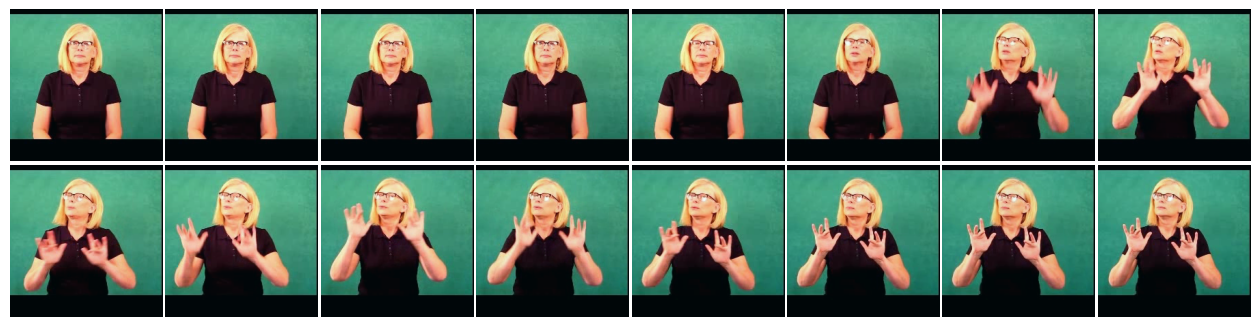

In [38]:
frames_aug, label_num = prep_next2(sample_aug)
print(f"frames: {frames_aug.shape}")
print(f'Class: {class_list[label_num]}')
utils.plt_display_grid(frames_aug,show_frames, size=figsize)

# Conclusion:

seems to be working?